# Emotion-Aware Adaptive Learning System
## Full ML Pipeline: Data Analysis, Clustering, and Supervised Learning

This notebook implements a complete pipeline for analyzing facial expression data
extracted via Amazon Rekognition during Arabic text reading sessions. The system
predicts stress levels using a hybrid unsupervised + supervised approach.

**Important Note:** Stress level labels are *pseudo-labels* derived from clustering,
not ground truth psychological assessments.

## 1. Data Loading & Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# Load datasets
train_df = pd.read_csv('TrainData.csv')
test_df = pd.read_csv('TestData.csv')

print(f"Training set: {train_df.shape[0]} samples, {train_df.shape[1]} features")
print(f"Testing set:  {test_df.shape[0]} samples, {test_df.shape[1]} features")
print(f"\nColumns: {list(train_df.columns)}")

Training set: 1263 samples, 8 features
Testing set:  1706 samples, 8 features

Columns: ['Frame', 'Emotion', 'Emotion_Confidence', 'Pose_Roll', 'Pose_Yaw', 'Pose_Pitch', 'Eye_Yaw', 'Eye_Pitch']


In [3]:
# Data validation
print("=== Training Data Summary ===")
print(train_df.describe().round(3))
print(f"\nMissing values:\n{train_df.isnull().sum()}")
print(f"\nDuplicate rows: {train_df.duplicated().sum()}")
print(f"\n=== Emotion Distribution (Train) ===")
print(train_df['Emotion'].value_counts())
print(f"\n=== Emotion Distribution (Test) ===")
print(test_df['Emotion'].value_counts())

=== Training Data Summary ===
          Frame  Emotion_Confidence  Pose_Roll  Pose_Yaw  Pose_Pitch  \
count  1263.000            1263.000   1263.000  1263.000    1263.000   
mean    631.000              83.033     -4.396    -2.122       4.802   
std     364.741              18.326      1.046     3.507       3.086   
min       0.000              29.174     -9.162   -11.630      -3.808   
25%     315.500              70.047     -5.027    -4.688       2.668   
50%     631.000              91.071     -4.339    -2.564       4.716   
75%     946.500              98.055     -3.726     0.235       6.736   
max    1262.000              99.931     -2.001     7.086      15.192   

        Eye_Yaw  Eye_Pitch  
count  1263.000   1263.000  
mean     -4.243    -10.875  
std       4.459      2.765  
min     -15.185    -23.706  
25%      -7.733    -12.106  
50%      -4.075    -10.380  
75%      -0.763     -9.205  
max      10.250     -3.678  

Missing values:
Frame                 0
Emotion            

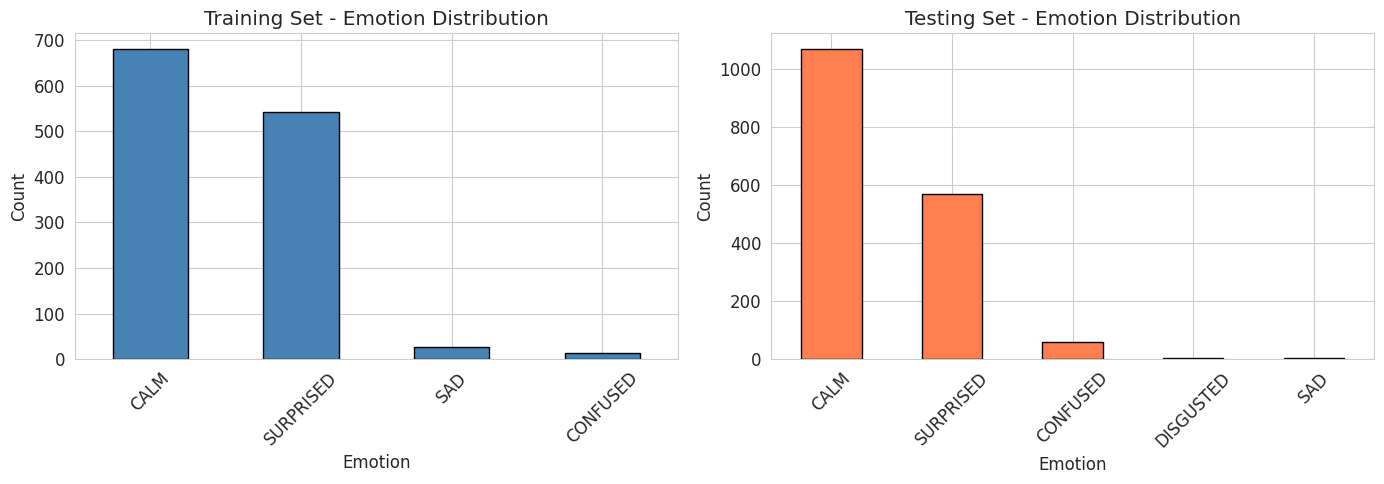


Class imbalance analysis:
  Train: Max/Min ratio = 52.4x (CALM vs CONFUSED)
  Test: Max/Min ratio = 267.5x (CALM vs SAD)


In [4]:
# Visualize emotion distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['Emotion'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Training Set - Emotion Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

test_df['Emotion'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Testing Set - Emotion Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nClass imbalance analysis:")
for name, df in [("Train", train_df), ("Test", test_df)]:
    counts = df['Emotion'].value_counts()
    ratio = counts.max() / counts.min()
    print(f"  {name}: Max/Min ratio = {ratio:.1f}x ({counts.idxmax()} vs {counts.idxmin()})")

## 2. Feature Engineering

In [5]:
def engineer_features(df):
    """Apply feature engineering to a dataframe."""
    result = df.copy()

    # One-hot encode emotions
    emotion_dummies = pd.get_dummies(result['Emotion'], prefix='Emotion')
    result = pd.concat([result, emotion_dummies], axis=1)

    # Derived features
    result['Pose_Magnitude'] = np.sqrt(
        result['Pose_Roll']**2 + result['Pose_Yaw']**2 + result['Pose_Pitch']**2
    )
    result['Eye_Magnitude'] = np.sqrt(
        result['Eye_Yaw']**2 + result['Eye_Pitch']**2
    )



    # Pose-Eye interaction
    result['Pose_x_Eye'] = result['Pose_Magnitude'] * result['Eye_Magnitude']


    print(f"  Original features: {df.shape[1]}, After engineering: {result.shape[1]}")
    return result

print("Engineering features for training set...")
train_eng = engineer_features(train_df)
print("Engineering features for testing set...")
test_eng = engineer_features(test_df)

print(f"\nNew features added: {list(set(train_eng.columns) - set(train_df.columns))}")

Engineering features for training set...
  Original features: 8, After engineering: 15
Engineering features for testing set...
  Original features: 8, After engineering: 16

New features added: ['Emotion_SURPRISED', 'Pose_Magnitude', 'Emotion_CONFUSED', 'Emotion_SAD', 'Pose_x_Eye', 'Eye_Magnitude', 'Emotion_CALM']


In [6]:
# Define feature columns for modeling
numeric_cols = ['Emotion_Confidence', 'Pose_Roll', 'Pose_Yaw', 'Pose_Pitch',
                'Eye_Yaw', 'Eye_Pitch', 'Pose_Magnitude', 'Eye_Magnitude',
                 'Pose_x_Eye']

# Add one-hot encoded emotion columns
emotion_cols = [c for c in train_eng.columns if c.startswith('Emotion_') and c != 'Emotion_Confidence']
feature_cols = numeric_cols + emotion_cols

print(f"Total features for modeling: {len(feature_cols)}")
print(f"  Numeric: {len(numeric_cols)}")
print(f"  Emotion one-hot: {len(emotion_cols)}")

# Normalize numerical features
scaler = StandardScaler()
train_features = train_eng[feature_cols].copy()
test_features = test_eng[feature_cols].copy()

train_features[numeric_cols] = scaler.fit_transform(train_features[numeric_cols])
test_features[numeric_cols] = scaler.transform(test_features[numeric_cols])

print("\nFeatures normalized using StandardScaler (fit on train, transform on test).")
print(f"\nTrain features shape: {train_features.shape}")
print(f"Test features shape:  {test_features.shape}")

Total features for modeling: 13
  Numeric: 9
  Emotion one-hot: 4

Features normalized using StandardScaler (fit on train, transform on test).

Train features shape: (1263, 13)
Test features shape:  (1706, 13)


## 3. Correlation Analysis

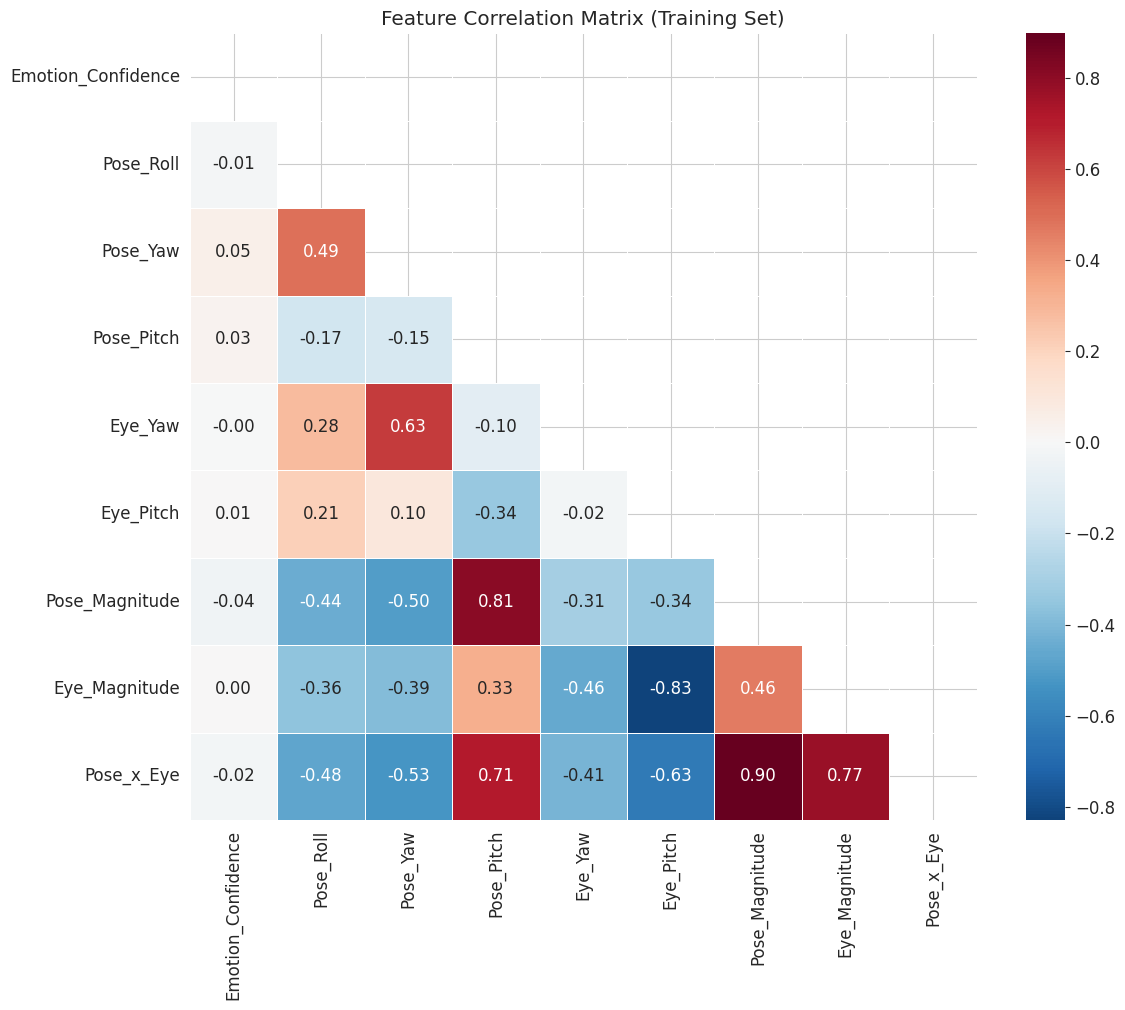


Highly correlated feature pairs (|r| > 0.8):
  Pose_Magnitude <-> Pose_x_Eye: r = 0.899
  Eye_Pitch <-> Eye_Magnitude: r = -0.830
  Pose_Pitch <-> Pose_Magnitude: r = 0.807


In [7]:
# Correlation heatmap for numeric features
corr_matrix = train_eng[numeric_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Training Set)')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                            corr_matrix.iloc[i, j]))

print("\nHighly correlated feature pairs (|r| > 0.8):")
for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1} <-> {f2}: r = {r:.3f}")
if not high_corr:
    print("  None found.")

## 4. Unsupervised Learning: GMM Clustering with BIC

In [8]:
# Evaluate GMM with different cluster sizes using BIC
k_range = range(2, 8)
bic_scores = []
aic_scores = []
gmm_models = {}

print("Evaluating GMM models:")
print(f"{'k':>3} | {'BIC':>12} | {'AIC':>12} | {'Log-Likelihood':>15}")
print("-" * 50)

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=5, max_iter=300)
    gmm.fit(train_features.values)
    bic = gmm.bic(train_features.values)
    aic = gmm.aic(train_features.values)
    bic_scores.append(bic)
    aic_scores.append(aic)
    gmm_models[k] = gmm
    print(f"{k:>3} | {bic:>12.1f} | {aic:>12.1f} | {gmm.score(train_features.values):>15.3f}")

optimal_k = list(k_range)[np.argmin(bic_scores)]
print(f"\nOptimal number of clusters (by BIC): k = {optimal_k}")

Evaluating GMM models:
  k |          BIC |          AIC |  Log-Likelihood
--------------------------------------------------
  2 |     -10233.6 |     -11308.2 |           4.642
  3 |     -20236.6 |     -21850.9 |           8.899
  4 |     -26519.8 |     -28674.0 |          11.683
  5 |     -27074.8 |     -29768.8 |          12.200
  6 |     -28246.8 |     -31480.6 |          12.961
  7 |     -28001.1 |     -31774.8 |          13.160

Optimal number of clusters (by BIC): k = 6


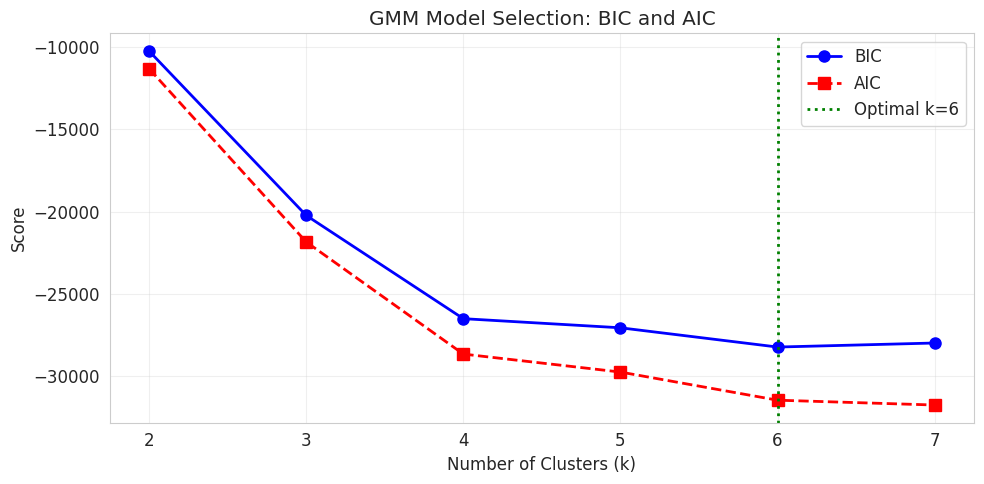

In [9]:
# Plot BIC and AIC scores
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), bic_scores, 'bo-', label='BIC', linewidth=2, markersize=8)
ax.plot(list(k_range), aic_scores, 'rs--', label='AIC', linewidth=2, markersize=8)
ax.axvline(x=optimal_k, color='green', linestyle=':', linewidth=2,
           label=f'Optimal k={optimal_k}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Score')
ax.set_title('GMM Model Selection: BIC and AIC')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Apply optimal GMM and generate pseudo-labels
best_gmm = gmm_models[optimal_k]
train_clusters = best_gmm.predict(train_features.values)
test_clusters = best_gmm.predict(test_features.values)

# Map clusters to stress levels based on cluster characteristics
# We analyze each cluster's mean Emotion_Confidence and Pose/Eye magnitudes
cluster_stats = pd.DataFrame()
for c in range(optimal_k):
    mask = train_clusters == c
    stats = train_eng.loc[mask, ['Emotion_Confidence', 'Pose_Magnitude', 'Eye_Magnitude']].mean()
    stats['count'] = mask.sum()
    stats['cluster'] = c
    cluster_stats = pd.concat([cluster_stats, stats.to_frame().T], ignore_index=True)

print("Cluster statistics (original scale):")
print(cluster_stats.to_string(index=False))

# Create stress score: higher pose/eye movement + lower confidence = higher stress
cluster_stats['stress_score'] = (
    cluster_stats['Pose_Magnitude'].rank() +
    cluster_stats['Eye_Magnitude'].rank() -
    cluster_stats['Emotion_Confidence'].rank()
)

# Sort by stress score and assign labels
stress_labels_map = {}
sorted_clusters = cluster_stats.sort_values('stress_score')
n_clusters = len(sorted_clusters)

if n_clusters == 2:
    labels = ['Low Stress', 'High Stress']
elif n_clusters == 3:
    labels = ['Low Stress', 'Medium Stress', 'High Stress']
else:
    labels = [f'Stress Level {i+1}' for i in range(n_clusters)]
    labels[0] = 'Low Stress'
    labels[-1] = 'High Stress'
    for i in range(1, n_clusters - 1):
        labels[i] = f'Medium Stress {i}' if n_clusters > 3 else 'Medium Stress'

for idx, (_, row) in enumerate(sorted_clusters.iterrows()):
    stress_labels_map[int(row['cluster'])] = labels[idx]

print(f"\nStress label mapping: {stress_labels_map}")

train_stress = pd.Series([stress_labels_map[c] for c in train_clusters], name='Stress_Level')
test_stress = pd.Series([stress_labels_map[c] for c in test_clusters], name='Stress_Level')

print(f"\n=== Pseudo-Label Distribution (Train) ===")
print(train_stress.value_counts())
print(f"\n=== Pseudo-Label Distribution (Test) ===")
print(test_stress.value_counts())

Cluster statistics (original scale):
 Emotion_Confidence  Pose_Magnitude  Eye_Magnitude  count  cluster
          83.540841        7.100115      11.122979  344.0      0.0
          84.146581        8.892240      13.973535  334.0      1.0
          66.442207        6.203788      10.314014   34.0      2.0
          49.554116        9.183315      13.797312   23.0      3.0
          82.344813       11.781743      17.158809  152.0      4.0
          85.406304        6.434250      10.394871  376.0      5.0

Stress label mapping: {5: 'Low Stress', 2: 'Medium Stress 1', 0: 'Medium Stress 2', 1: 'Medium Stress 3', 3: 'Medium Stress 4', 4: 'High Stress'}

=== Pseudo-Label Distribution (Train) ===
Stress_Level
Low Stress         376
Medium Stress 2    344
Medium Stress 3    334
High Stress        152
Medium Stress 1     34
Medium Stress 4     23
Name: count, dtype: int64

=== Pseudo-Label Distribution (Test) ===
Stress_Level
High Stress        729
Medium Stress 2    369
Medium Stress 3    287
Low

## 5. Cluster Validation: PCA Visualization

PCA explained variance: PC1=0.439, PC2=0.154, Total=0.593


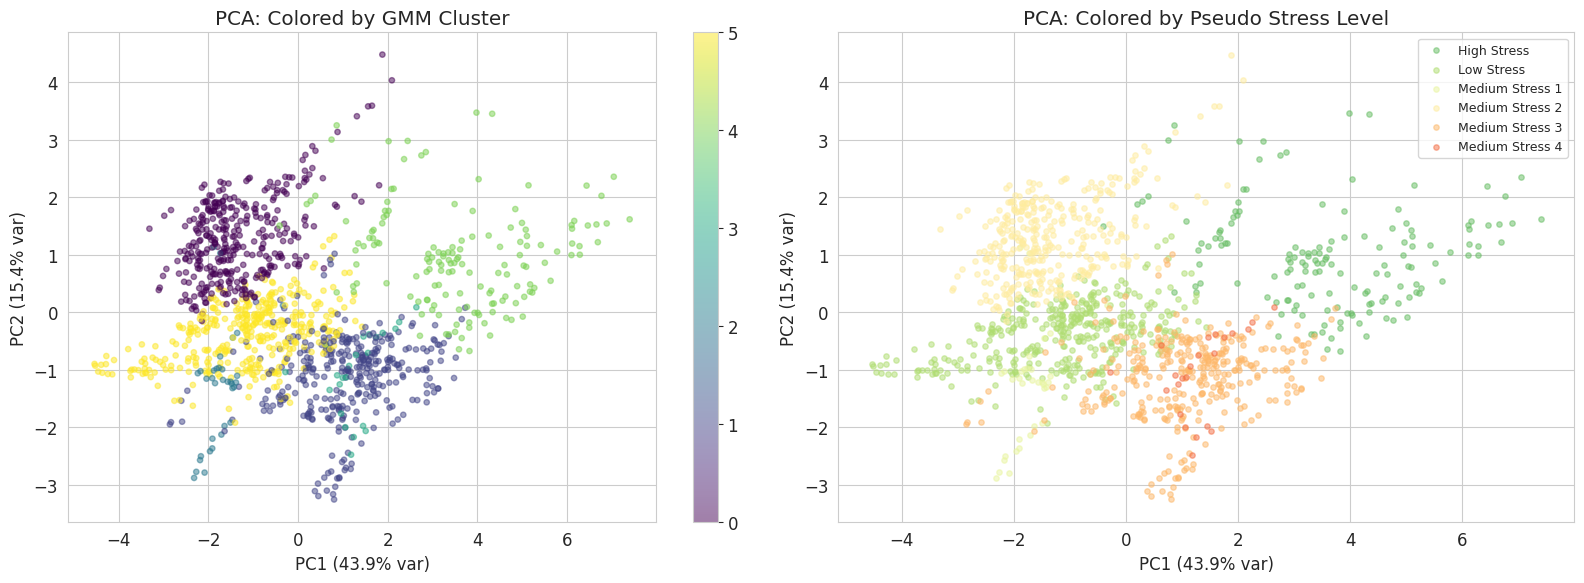

In [11]:
# PCA for 2D visualization
pca = PCA(n_components=2)
train_pca = pca.fit_transform(train_features.values)

print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2={pca.explained_variance_ratio_[1]:.3f}, "
      f"Total={sum(pca.explained_variance_ratio_):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by cluster
scatter1 = axes[0].scatter(train_pca[:, 0], train_pca[:, 1], c=train_clusters,
                           cmap='viridis', alpha=0.5, s=15)
axes[0].set_title('PCA: Colored by GMM Cluster')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(scatter1, ax=axes[0])

# Color by stress level
unique_stress = sorted(train_stress.unique())
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(unique_stress)))
for i, level in enumerate(unique_stress):
    mask = train_stress == level
    axes[1].scatter(train_pca[mask, 0], train_pca[mask, 1],
                   c=[colors[i]], alpha=0.5, s=15, label=level)
axes[1].set_title('PCA: Colored by Pseudo Stress Level')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Feature Selection

Feature Importance (Mutual Information with Pseudo-Labels):
           Feature  MI_Score
           Eye_Yaw  0.838379
          Pose_Yaw  0.697998
        Pose_x_Eye  0.564542
     Eye_Magnitude  0.408920
    Pose_Magnitude  0.363119
        Pose_Pitch  0.328484
         Eye_Pitch  0.279505
         Pose_Roll  0.219802
Emotion_Confidence  0.067270
       Emotion_SAD  0.061421
      Emotion_CALM  0.022392
 Emotion_SURPRISED  0.021983
  Emotion_CONFUSED  0.006045


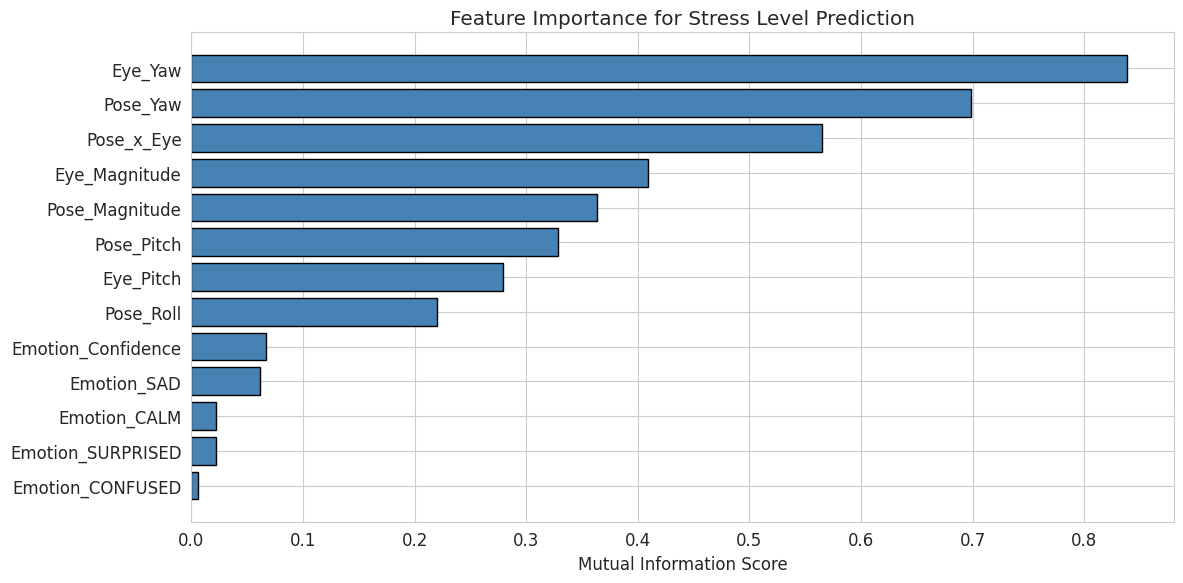


Selected 6 features (MI > 0.2985):
  - Eye_Yaw
  - Pose_Yaw
  - Pose_x_Eye
  - Eye_Magnitude
  - Pose_Magnitude
  - Pose_Pitch


In [12]:
# Mutual information for feature importance relative to pseudo-labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(train_stress)

mi_scores = mutual_info_classif(train_features.values, y_train_encoded, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

print("Feature Importance (Mutual Information with Pseudo-Labels):")
print(mi_df.to_string(index=False))

# Plot
plt.figure(figsize=(12, 6))
plt.barh(mi_df['Feature'], mi_df['MI_Score'], color='steelblue', edgecolor='black')
plt.xlabel('Mutual Information Score')
plt.title('Feature Importance for Stress Level Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Select top features (MI > threshold or top N)
threshold = mi_df['MI_Score'].mean()
selected_features = mi_df[mi_df['MI_Score'] > threshold]['Feature'].tolist()
print(f"\nSelected {len(selected_features)} features (MI > {threshold:.4f}):")
for f in selected_features:
    print(f"  - {f}")

## 7. Supervised Learning: Gradient Boosting

In [13]:
# Prepare data with selected features
X_train = train_features[selected_features].values
X_test = test_features[selected_features].values
y_train = y_train_encoded
y_test = le.transform(test_stress)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"Classes: {le.classes_}")

# Handle class imbalance with sample weights
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)
print(f"\nClass distribution (train): {dict(zip(le.classes_, np.bincount(y_train)))}")
print("Using balanced sample weights to handle class imbalance.")

Training set: (1263, 6)
Testing set:  (1706, 6)
Classes: ['High Stress' 'Low Stress' 'Medium Stress 1' 'Medium Stress 2'
 'Medium Stress 3' 'Medium Stress 4']

Class distribution (train): {'High Stress': np.int64(152), 'Low Stress': np.int64(376), 'Medium Stress 1': np.int64(34), 'Medium Stress 2': np.int64(344), 'Medium Stress 3': np.int64(334), 'Medium Stress 4': np.int64(23)}
Using balanced sample weights to handle class imbalance.


In [14]:
# Train Gradient Boosting with cross-validation
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_split=10,
    random_state=42
)

# Cross-validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_model, X_train, y_train, cv=cv, scoring='accuracy')

print("=== Cross-Validation Results (Training Set) ===")
print(f"Fold scores: {cv_scores.round(4)}")
print(f"Mean accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Fit final model
gb_model.fit(X_train, y_train, sample_weight=sample_weights)
print("\nModel trained on full training set.")

=== Cross-Validation Results (Training Set) ===
Fold scores: [0.9644 0.9526 0.9526 0.9643 0.9603]
Mean accuracy: 0.9588 ± 0.0053

Model trained on full training set.


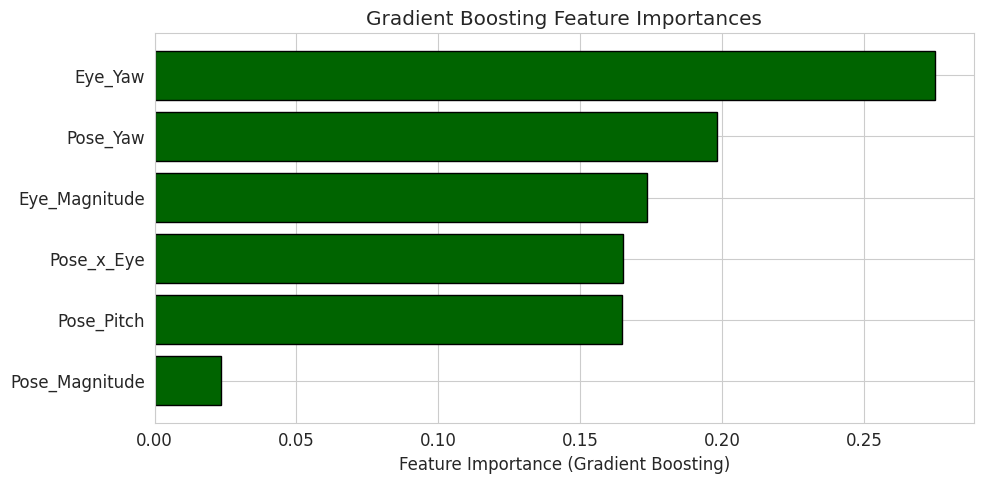

Gradient Boosting Feature Importances:
       Feature  Importance
       Eye_Yaw    0.274986
      Pose_Yaw    0.198109
 Eye_Magnitude    0.173580
    Pose_x_Eye    0.165057
    Pose_Pitch    0.164747
Pose_Magnitude    0.023521


In [15]:
# Feature importance from Gradient Boosting
gb_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(gb_importance['Feature'], gb_importance['Importance'],
         color='darkgreen', edgecolor='black')
plt.xlabel('Feature Importance (Gradient Boosting)')
plt.title('Gradient Boosting Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Gradient Boosting Feature Importances:")
print(gb_importance.to_string(index=False))

## 8. Evaluation

In [17]:
# Test set performance
y_test_pred = gb_model.predict(X_test)
print("=== Test Set Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

=== Test Set Performance ===
Accuracy: 0.7573

Classification Report:
                 precision    recall  f1-score   support

    High Stress       0.91      0.74      0.81       729
     Low Stress       0.66      0.97      0.79       254
Medium Stress 1       0.05      0.04      0.04        56
Medium Stress 2       0.78      0.83      0.80       369
Medium Stress 3       0.64      0.70      0.67       287
Medium Stress 4       0.00      0.00      0.00        11

       accuracy                           0.76      1706
      macro avg       0.51      0.54      0.52      1706
   weighted avg       0.77      0.76      0.75      1706



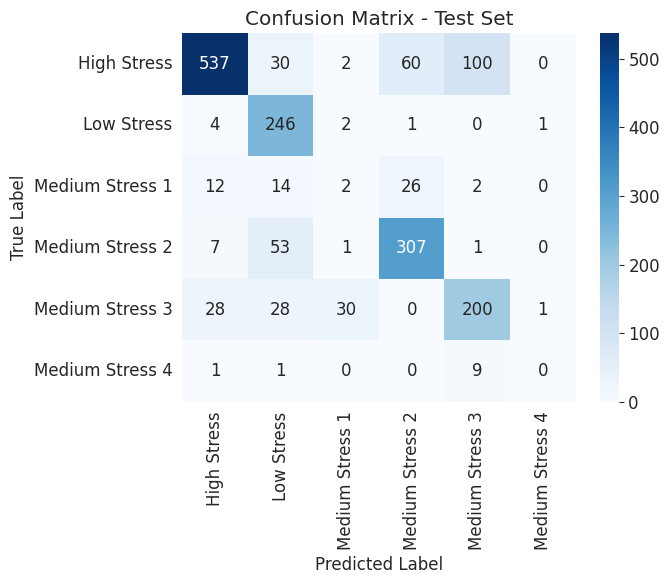

In [19]:
# Confusion matrix (Single plot)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 9. Adaptive Learning Strategy

## 10. Summary & Scientific Validity Notes

### Key Results
- **Optimal clusters (BIC):** Used GMM to discover natural groupings in the data
- **Pseudo-labels:** Stress levels derived from unsupervised clustering (NOT ground truth)
- **Model:** Gradient Boosting classifier trained on pseudo-labels
- **Evaluation:** Cross-validated on training set, independently evaluated on held-out test set

### Important Caveats
1. **Pseudo-labels ≠ Ground Truth:** The stress levels are data-driven approximations, not clinically validated
2. **Model performance reflects pattern learning:** High accuracy means the model captures the clustering structure, not that it measures real psychological stress
3. **Future work:** Integration with live camera feed and real-time prediction pipeline
